In [173]:
from utils_gene import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Taille du fichier : 182851 octets
Graphe initial : Nodes : 198, Edges : 2742
Variance cible (SBM) : 0.05615624
------------------------------
Erreur moyenne sur les degrés (MAE) : 0.004235
Step 01 | Sigma testé: 19.1014 | Var: 0.07746053 | Δ: 2.13e-02
Erreur moyenne sur les degrés (MAE) : 0.014584
Step 02 | Sigma testé: 30.9036 | Var: 0.09057727 | Δ: 3.44e-02
Erreur moyenne sur les degrés (MAE) : 0.001189
Step 03 | Sigma testé: 11.8072 | Var: 0.06068143 | Δ: 4.53e-03
Erreur moyenne sur les degrés (MAE) : 0.000601
Step 04 | Sigma testé: 7.2992 | Var: 0.04288661 | Δ: 1.33e-02
Erreur moyenne sur les degrés (MAE) : 0.001170
Step 05 | Sigma testé: 11.7216 | Var: 0.06040735 | Δ: 4.25e-03
Erreur moyenne sur les degrés (MAE) : 0.000978
Step 06 | Sigma testé: 10.7720 | Var: 0.05720710 | Δ: 1.05e-03
Erreur moyenne sur les degrés (MAE) : 0.000779
Step 07 | Sigma testé: 9.4455 | Var: 0.05222331 | Δ: 3.93e-03
Erreur moyenne sur les degrés (MAE) : 0.000937
Step 08 | Sigma testé: 10.5382 | Var: 0.056

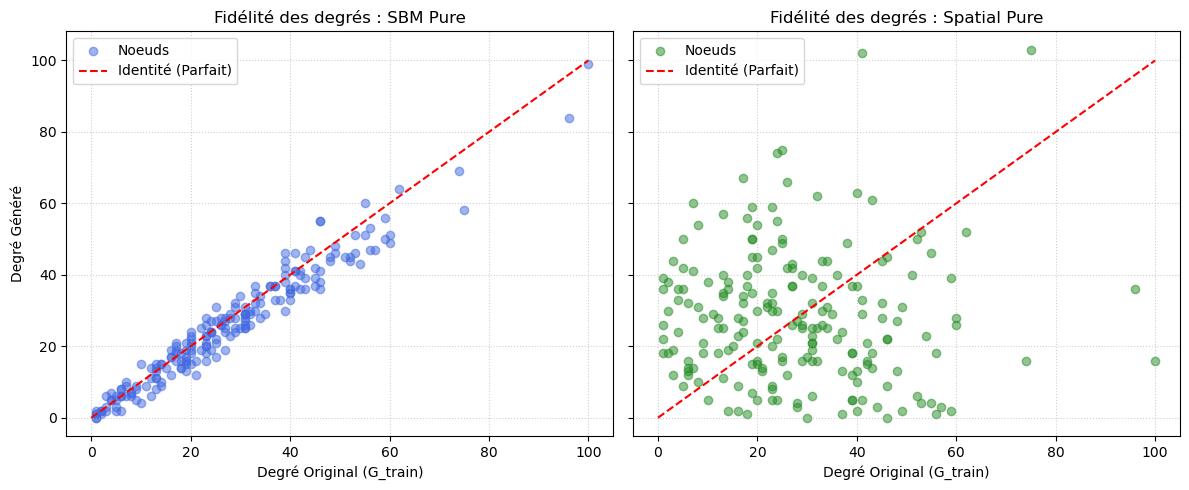

Erreur Moyenne Absolue (MAE) SBM     : 3.29
Erreur Moyenne Absolue (MAE) Spatial : 20.49
Proba moyenne pour les arêtes réelles : 0.542769
Proba min pour une arête réelle : 0.001371060631
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.560830
Proba min pour une arête réelle : 0.002486068634
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [176]:
G_name = "reel_jazz_collab_w_attributes.joblib"
path = f"../../graph_library/{G_name}"
print(f"Taille du fichier : {os.path.getsize(path)} octets")

G = joblib.load(path)
print(f"Graphe initial : Nodes : {G.number_of_nodes()}, Edges : {G.number_of_edges()}")

e_rs, k, commus = get_real_graph_properties_sbm_V2(G)
#P_sbm = get_probs_sbm_non_DC(e_rs, commus)
P_sbm = get_probs_sbm_DC(e_rs, k , commus)

degrees, position = get_real_graph_properties_pos_V2(G)
sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees, position, DC=True)
#P_spatial = get_probs_spatial_non_DC(position, n_liens_target= G.number_of_edges(), sigma = sigma_opt)
P_spatial, degrees = get_probs_spatial_DC(degrees, position, sigma = sigma_opt)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, k, degrees, commus, e_rs)
g_sbm_nx = convert_to_nx_with_metadata(g_sbm, position, k, degrees, commus, e_rs, P_sbm)


print(f"P_SBM : {P_sbm[2][3]}")
print(f"P_SBM : {P_sbm[3][2]}")

nu = g_spatial_nx.nodes[0]
print(f"DEBUG: Attr cherché: | Présents dans nu: {list(nu.keys())}")

print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")

plot_degree_correlation(k, g_sbm, g_spatial)
#visualize_generation_diagnostics_v2(P_sbm, P_spatial, k, e_rs, b)

analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

In [177]:
Hybrid_ratios_list = np.arange(0.00, 1.25, 0.25)

generate_graph_benchmarks(Hybrid_ratios_list, P_sbm, P_spatial, position, k, degrees, commus, 
                          e_rs, name="artificial_graph_sbmv5", save_P_matrix=True)


Pour ratio_sbm = 0.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_00_pos_1_00.graphml

Pour ratio_sbm = 0.25

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_25_pos_0_75.graphml

Pour ratio_sbm = 0.5

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_50_pos_0_50.graphml

Pour ratio_sbm = 0.75

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_75_pos_0_25.graphml

Pour ratio_sbm = 1.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_1_00_pos_0_00.graphml

📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION
             Modèle    N     E    Variance  Entropy Log-Likelihood Clustering
0  Hybride (α=0.00)  198  2728  0.05615625  6007.34       -6166.88     0.3703
1  Hybride (α=0.25)  198  2696  0.03492358  7762.79       -7710.81     0.2805
2  Hybride (α=0.50)  198  2688  0.02784602  8144.73       -8055.14     0.2377
3  Hybride (α=0.75)  198  2630  0.

In [179]:
G = load_graphml_safe("../../graph_library/artificial_graph_sbmv5_1_00_pos_0_00.graphml")
plot_sbm_density_comparison(G)

Graphe chargé : 198 nœuds et 2533 liens.
Erreur : L'attribut 'GT_true_probs' est introuvable.


In [173]:
from utils_gene import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Taille du fichier : 182851 octets
Graphe initial : Nodes : 198, Edges : 2742
Variance cible (SBM) : 0.05615624
------------------------------
Erreur moyenne sur les degrés (MAE) : 0.004235
Step 01 | Sigma testé: 19.1014 | Var: 0.07746053 | Δ: 2.13e-02
Erreur moyenne sur les degrés (MAE) : 0.014584
Step 02 | Sigma testé: 30.9036 | Var: 0.09057727 | Δ: 3.44e-02
Erreur moyenne sur les degrés (MAE) : 0.001189
Step 03 | Sigma testé: 11.8072 | Var: 0.06068143 | Δ: 4.53e-03
Erreur moyenne sur les degrés (MAE) : 0.000601
Step 04 | Sigma testé: 7.2992 | Var: 0.04288661 | Δ: 1.33e-02
Erreur moyenne sur les degrés (MAE) : 0.001170
Step 05 | Sigma testé: 11.7216 | Var: 0.06040735 | Δ: 4.25e-03
Erreur moyenne sur les degrés (MAE) : 0.000978
Step 06 | Sigma testé: 10.7720 | Var: 0.05720710 | Δ: 1.05e-03
Erreur moyenne sur les degrés (MAE) : 0.000779
Step 07 | Sigma testé: 9.4455 | Var: 0.05222331 | Δ: 3.93e-03
Erreur moyenne sur les degrés (MAE) : 0.000937
Step 08 | Sigma testé: 10.5382 | Var: 0.056

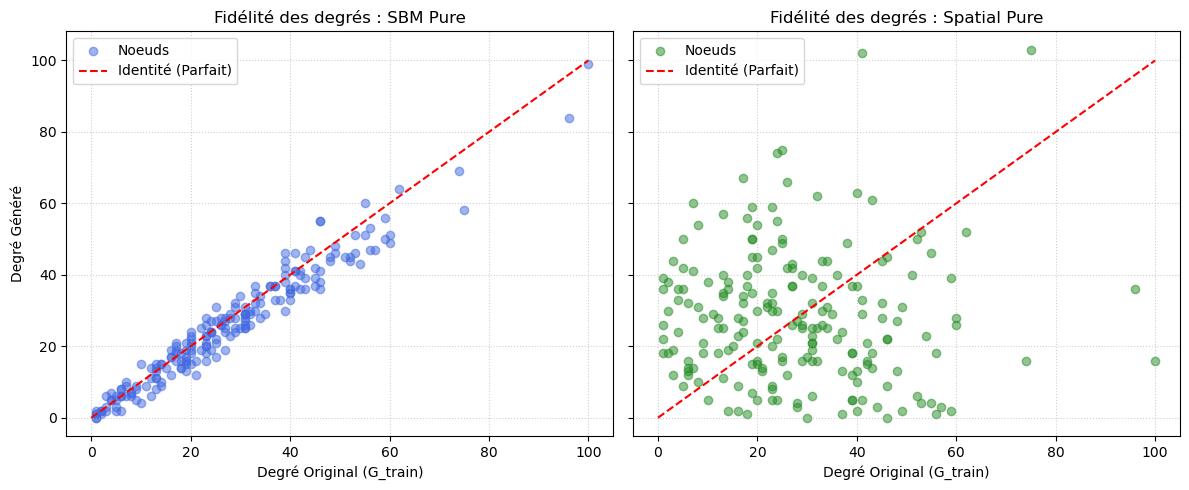

Erreur Moyenne Absolue (MAE) SBM     : 3.29
Erreur Moyenne Absolue (MAE) Spatial : 20.49
Proba moyenne pour les arêtes réelles : 0.542769
Proba min pour une arête réelle : 0.001371060631
Nombre d'arêtes 'impossibles' selon le modèle : 0
Proba moyenne pour les arêtes réelles : 0.560830
Proba min pour une arête réelle : 0.002486068634
Nombre d'arêtes 'impossibles' selon le modèle : 0


In [176]:
G_name = "reel_jazz_collab_w_attributes.joblib"
path = f"../../graph_library/{G_name}"
print(f"Taille du fichier : {os.path.getsize(path)} octets")

G = joblib.load(path)
print(f"Graphe initial : Nodes : {G.number_of_nodes()}, Edges : {G.number_of_edges()}")

e_rs, k, commus = get_real_graph_properties_sbm_V2(G)
#P_sbm = get_probs_sbm_non_DC(e_rs, commus)
P_sbm = get_probs_sbm_DC(e_rs, k , commus)

degrees, position = get_real_graph_properties_pos_V2(G)
sigma_opt, P_spatial_calibrated = match_spatial_to_sbm_variance(P_sbm, degrees, position, DC=True)
#P_spatial = get_probs_spatial_non_DC(position, n_liens_target= G.number_of_edges(), sigma = sigma_opt)
P_spatial, degrees = get_probs_spatial_DC(degrees, position, sigma = sigma_opt)

g_sbm = generate_graph_from_probs(P_sbm)
g_spatial = generate_graph_from_probs(P_spatial)
g_spatial_nx = convert_to_nx_with_metadata(g_spatial, position, k, degrees, commus, e_rs)
g_sbm_nx = convert_to_nx_with_metadata(g_sbm, position, k, degrees, commus, e_rs, P_sbm)


print(f"P_SBM : {P_sbm[2][3]}")
print(f"P_SBM : {P_sbm[3][2]}")

nu = g_spatial_nx.nodes[0]
print(f"DEBUG: Attr cherché: | Présents dans nu: {list(nu.keys())}")

print(f"SBM VS spatial = {g_sbm.num_edges()} VS {g_spatial.num_edges()}")

entropy_sbm = get_entropy_from_p(P_sbm)
log_likelyhood_sbm = get_log_likelihood(g_sbm, P_sbm)
entropy_spatial = get_entropy_from_p(P_spatial)
log_likelyhood_spatial = get_log_likelihood(g_spatial, P_spatial)
var_sbm = get_variance_from_P(P_sbm)
var_spatial = get_variance_from_P(P_spatial)

print(f" Entropy VS Log_likelyhood SBM : {entropy_sbm} / {log_likelyhood_sbm}")
print(f" Entropy VS Log_likelyhood Spatial : {entropy_spatial} / {log_likelyhood_spatial}")
print(f" Variance SBM VS Spatial : {var_sbm} / {var_spatial}")

plot_degree_correlation(k, g_sbm, g_spatial)
#visualize_generation_diagnostics_v2(P_sbm, P_spatial, k, e_rs, b)

analyze_errors(g_spatial, P_spatial)
analyze_errors(g_sbm, P_sbm)

In [177]:
Hybrid_ratios_list = np.arange(0.00, 1.25, 0.25)

generate_graph_benchmarks(Hybrid_ratios_list, P_sbm, P_spatial, position, k, degrees, commus, 
                          e_rs, name="artificial_graph_sbmv5", save_P_matrix=True)


Pour ratio_sbm = 0.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_00_pos_1_00.graphml

Pour ratio_sbm = 0.25

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_25_pos_0_75.graphml

Pour ratio_sbm = 0.5

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_50_pos_0_50.graphml

Pour ratio_sbm = 0.75

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_0_75_pos_0_25.graphml

Pour ratio_sbm = 1.0

Graphe exporté avec succès dans : ../../graph_library/artificial_graph_sbmv5_1_00_pos_0_00.graphml

📊 TABLEAU RÉCAPITULATIF DE L'HYBRIDATION
             Modèle    N     E    Variance  Entropy Log-Likelihood Clustering
0  Hybride (α=0.00)  198  2728  0.05615625  6007.34       -6166.88     0.3703
1  Hybride (α=0.25)  198  2696  0.03492358  7762.79       -7710.81     0.2805
2  Hybride (α=0.50)  198  2688  0.02784602  8144.73       -8055.14     0.2377
3  Hybride (α=0.75)  198  2630  0.

In [179]:
G = load_graphml_safe("../../graph_library/artificial_graph_sbmv5_1_00_pos_0_00.graphml")
plot_sbm_density_comparison(G)

Graphe chargé : 198 nœuds et 2533 liens.
Erreur : L'attribut 'GT_true_probs' est introuvable.
